In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [221]:
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        """ this is to render result instead of cryptic output in Python """
        return f"Value(data={self.data})"

    def __add__(self, operand):
        operand = operand if isinstance(operand, Value) else Value(operand)
        
        out = Value(self.data + operand.data, (self, operand), '+')

        """ plus-op just copies grad result """
        def _backward():
            self.grad += 1.0 * out.grad
            operand.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out

    def __mul__(self, operand):
        operand = operand if isinstance(operand, Value) else Value(operand)
        
        out = Value(self.data * operand.data, (self, operand), '*')

        def _backward():
            self.grad += operand.data * out.grad
            operand.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad = (1 - out.data ** 2) * out.grad
        out._backward = _backward
        
        return out

    def backward(self):
        topo = []
        
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    # FIXES to address "1 + Value(2.0)"
    def __radd__(self, other): # other + self
        return self + other
    def __rmul__(self, other): # other * self
        return self * other

In [222]:
# inputs x
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of neuron
b = Value(6.8813, label='b')
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
# body on neuron without activation func
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'output O'

o.backward()

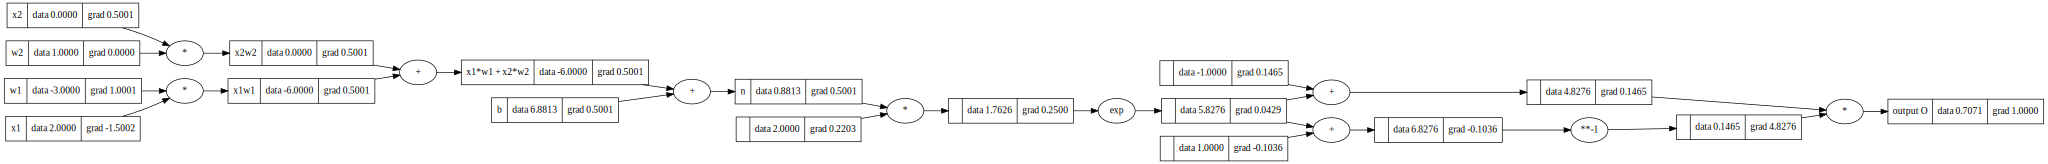

In [252]:
# import draw_dot
# draw_dot.draw_dot(o)

# OR
%run draw_dot.py
draw_dot(o)

In [118]:
a = Value(2.0)
b = Value(4.0)

# Let's add '-', '/' 'exp' ops, so we ca add more nodes for tanH-op. later we will need these for tuning and handling negativ signals

design of tanH/activation functions is completely up to you

# Fun fact about e^x Key Property

e^x derivative is e^x itself

e^x is the only function (up to a constant multiple) that equals its own derivative. This makes it fundamental in:

- Solving differential equations
- Compound interest/continuous growth
- Neural network activations (since gradients flow cleanly)

In [523]:
def exp(self): # to toy with tanH substitute
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
        self.grad += out.data * out.grad
    out._backward = _backward

    return out

Value.exp = exp

In [524]:

b / a
# a.backward()
# a.exp()

Value(data=3.44065)

# hacky way to handle division using power(-1)
b / a = b * a**-1

In [525]:
def __pow__(self, other):
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += (other * self.data**(other-1)) * out.grad
    out._backward = _backward

    return out
    
def __truediv__(self, other): # self / other
    return self * other**-1

Value.__pow__ = __pow__
Value.__truediv__ = __truediv__

a ** -1
b / a

Value(data=3.44065)

# add Negation and substraction

In [526]:
def __neg__(self): # -self
    return self * -1

def __sub__(self, other): # self - other
    return self + (-other)

Value.__neg__ = __neg__
Value.__sub__ = __sub__

a - b

Value(data=-4.8813)

instead of tanH we will use e-number from under the hood to get 'o' now

![img](https://wikimedia.org/api/rest_v1/media/math/render/svg/b8dc4c309a551cafc2ce5c883c924ecd87664b0f)

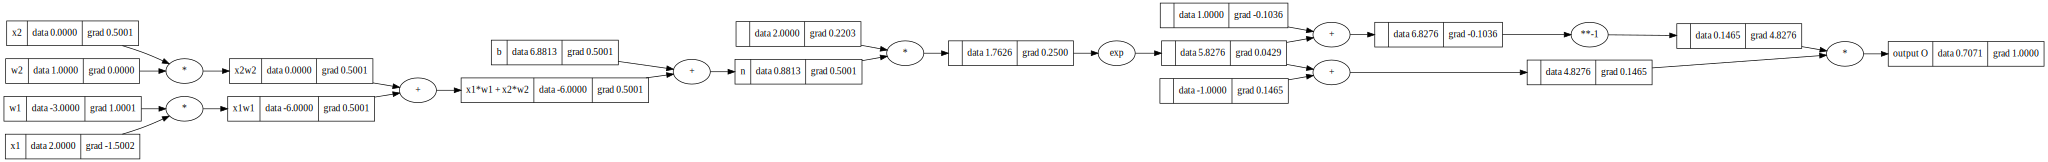

In [527]:
# inputs x
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of neuron
b = Value(6.8813, label='b')
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
# body on neuron without activation func
n = x1w1x2w2 + b; n.label = 'n'

############ instead of tanH we use 'exp' used under the hood directly to define 'o'
e2x = (2 * n).exp()
o = (e2x - 1) / (e2x + 1)

o.label = 'output O'

o.backward()
draw_dot(o)

# PyTorch

we can do all of that automatically with pyTorch

In [528]:
!pip install torch
#  1.5-2Gb

In [529]:
import torch

In [530]:
x1 = torch.Tensor([2.0]).double();   x1.requires_grad = True # pyTorch needs explicit grad definition, due to efficiency reasons
x2 = torch.Tensor([0.0]).double();   x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double();  w1.requires_grad = True
w2 = torch.Tensor([1.0]).double();   w2.requires_grad = True
b = torch.Tensor([6.8813]).double(); b.requires_grad = True 

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('-----')
print('x1:', x1.grad.item())
print('x2:', x2.grad.item())
print('w1:', w1.grad.item())
print('w2:', w2.grad.item())


0.7070699720278941
-----
x1: -1.5001561639694192
x2: 0.5000520546564731
w1: 1.0001041093129461
w2: 0.0


In [531]:
# torch.Tensor([[1, 2, 3], [4, 5, 6]]).shape # usually that is what we do in ML
torch.Tensor([2.0]).double() # double is used to make it float64(double precision point


tensor([2.], dtype=torch.float64)

# Neuron

reminder:

![image](https://www.researchgate.net/publication/364814302/figure/fig5/AS:11431281092677232@1666928276027/Neural-net-Structure-with-an-Activation-Function-Source-CS231n-Stanford-2017.png)


In [532]:
import random

class RandomNeuron:
    def __init__(self, number_of_inputs_for_a_neuron):
        self.weights = [Value(random.uniform(-1,1), label='w') for _ in range(number_of_inputs_for_a_neuron)]
        self.bias = Value(random.uniform(-1,1), label='b')


    ''' x = [2.0, 3.0]
        n = Neuron(2) 
        n((x) # ==> uses __call__ under the hood
    '''
    def __call__(self, x):
        # w + x + b
        neuron_body = sum(
            wi * xi for wi, xi in zip(self.weights, x) 
        ) + self.bias
        return neuron_body.tanh()

list_of_signals_x = [2.0, 3.0]
n = RandomNeuron(2)
n(list_of_signals_x)   

Value(data=-0.9823601454426639)

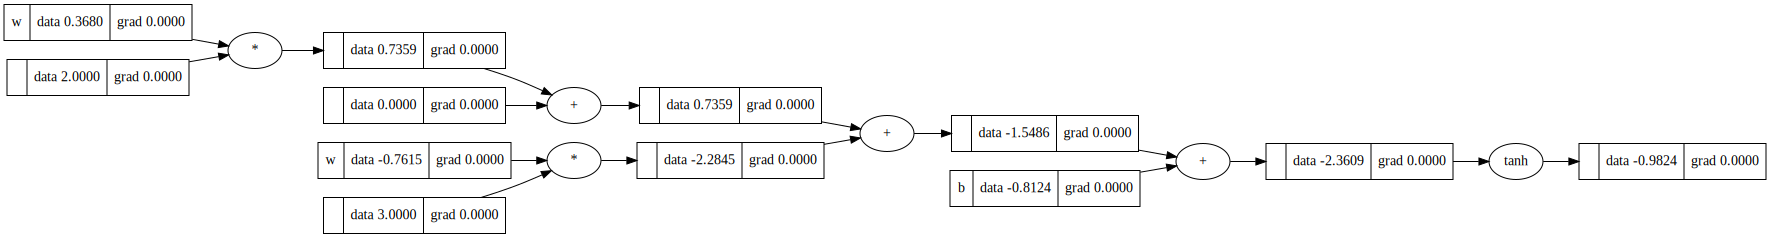

In [533]:
draw_dot(n(list_of_signals_x)   )

# Layer of neurons

![MLP](https://www.researchgate.net/publication/334609713/figure/fig1/AS:783455927406593@1563801857102/Multi-Layer-Perceptron-MLP-diagram-with-four-hidden-layers-and-a-collection-of-single.jpg)

In [534]:
class LayerOfRandomNeurons:
    def __init__(self, number_of_inputs_for_a_neuron, number_of_layer_neuron_outputs):
        self.neurons = [RandomNeuron(number_of_inputs_for_a_neuron) for _ in range(number_of_layer_neuron_outputs)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]

        return out[0] if len(out) == 1 else out
        
        

list_of_signals_x = [2.0, 3.0]
layer = LayerOfRandomNeurons(2, 3)
layer(list_of_signals_x)  

[Value(data=0.4686147363462163),
 Value(data=0.9824521654952197),
 Value(data=-0.9967947124316835)]

# Multi layer perceptron

![impmlp](mlp.jpeg)

In [535]:
class MultiLayerPerceptron:
    def __init__(self, number_of_inputs_for_a_neuron, list_of_numbers_of_layer_neuron_outputs):
        sz = [number_of_inputs_for_a_neuron] + list_of_numbers_of_layer_neuron_outputs
        self.layers = [
            LayerOfRandomNeurons(sz[i], sz[i+1]) for i in range(len(list_of_numbers_of_layer_neuron_outputs))
        ]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

list_of_signals_x = [2.0, 3.0, -1.0]

# refer pic above. we build perceptron for hidden and output layers, and call in with a list of signals fron the input layer
# input_layer_size = 3 # og list_of_signals_x.length
# hidden_layer_1_size = 4
# hidden_layer_2_size = 4
# output_layer_size = 1
mlp = MultiLayerPerceptron(3, [4, 4, 1])
mlp(list_of_signals_x)  

Value(data=-0.7971724839199311)

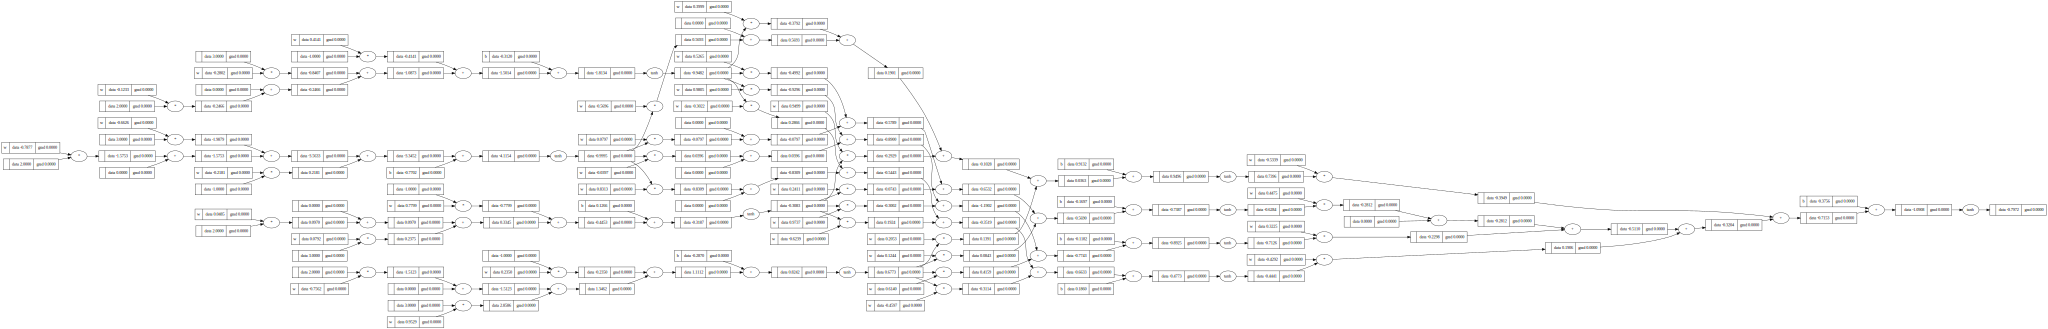

In [536]:
draw_dot(mlp(list_of_signals_x))